# Machine Learning Workshop — Mini Projects Notebook
### Supervised Learning & Unsupervised Learning in Practice



| # | Project | ML Type | Task |
|---|---------|---------|------|
| 1 | Customer Churn Prediction | Supervised | Classification |
| 2 | House Price Prediction | Supervised | Regression |
| 3 | Customer Segmentation | Unsupervised | Clustering |

Each project follows the same workflow taught in the concept notebooks:

**Generate/Load Data → EDA → Preprocessing → Model Training → Evaluation → Insights**


## 0. Setup — Common Imports
Run this cell first. It is used by all three projects below.

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Supervised models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Unsupervised models
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.


---
## Project 1 — Customer Churn Prediction
### *Supervised Learning: Classification*

**Goal:** predict whether a telecom customer will churn (leave the service)
based on their usage behaviour.

We simulate a dataset with realistic-feeling features and build the churn
label from a logistic function of those features plus noise — so there is a
genuine, learnable (but not perfect) signal for the models to find.


### 1.1 Generate Synthetic Data

In [2]:
n_customers = 2000

tenure_months = np.random.randint(1, 72, n_customers)
monthly_charges = np.round(np.random.normal(65, 20, n_customers).clip(20, 150), 2)
support_calls = np.random.poisson(1.5, n_customers)
contract_type = np.random.choice(
    ["Month-to-month", "One year", "Two year"],
    size=n_customers, p=[0.55, 0.25, 0.20]
)
has_internet = np.random.choice(["Yes", "No"], size=n_customers, p=[0.8, 0.2])

# Build churn probability from a logistic combination of features
contract_risk = np.select(
    [contract_type == "Month-to-month", contract_type == "One year", contract_type == "Two year"],
    [1.2, 0.2, -0.8]
)

z = (
    -1.8
    - 0.04 * tenure_months
    + 0.015 * monthly_charges
    + 0.35 * support_calls
    + contract_risk
    + np.random.normal(0, 0.6, n_customers)  # noise
)
churn_prob = 1 / (1 + np.exp(-z))
churn = (churn_prob > np.random.uniform(0.4, 0.6, n_customers)).astype(int)

df_churn = pd.DataFrame({
    "tenure_months": tenure_months,
    "monthly_charges": monthly_charges,
    "support_calls": support_calls,
    "contract_type": contract_type,
    "has_internet": has_internet,
    "churn": churn
})

df_churn.head()


,tenure_months,monthly_charges,support_calls,contract_type,has_internet,churn
0,52,78.56,0,One year,Yes,0
1,15,55.24,0,One year,Yes,0
2,61,108.15,3,One year,Yes,0
3,21,52.89,2,Month-to-month,No,0
4,24,79.84,0,Month-to-month,Yes,0


### 1.2 Exploratory Data Analysis (EDA)

In [3]:
print(df_churn.shape)
df_churn.info()
print("\nChurn rate:", df_churn["churn"].mean().round(3))


(2000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure_months    2000 non-null   int64  
 1   monthly_charges  2000 non-null   float64
 2   support_calls    2000 non-null   int64  
 3   contract_type    2000 non-null   object 
 4   has_internet     2000 non-null   object 
 5   churn            2000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 93.9+ KB

Churn rate: 0.202


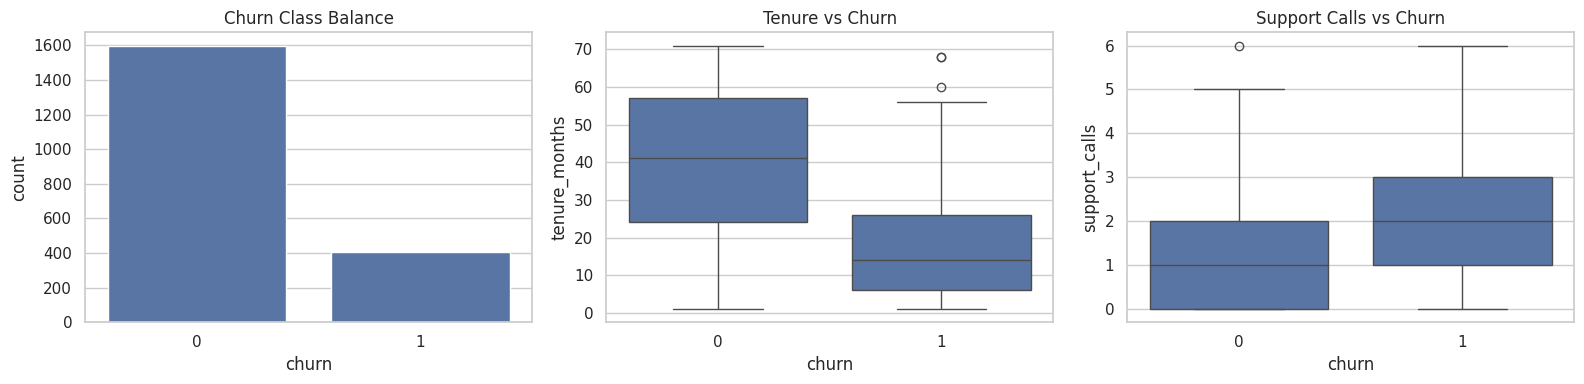

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_churn, x="churn", ax=axes[0])
axes[0].set_title("Churn Class Balance")

sns.boxplot(data=df_churn, x="churn", y="tenure_months", ax=axes[1])
axes[1].set_title("Tenure vs Churn")

sns.boxplot(data=df_churn, x="churn", y="support_calls", ax=axes[2])
axes[2].set_title("Support Calls vs Churn")

plt.tight_layout()
plt.show()


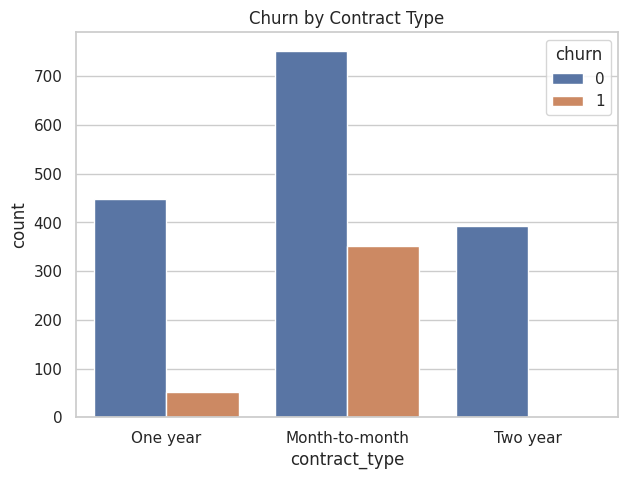

In [5]:
sns.countplot(data=df_churn, x="contract_type", hue="churn")
plt.title("Churn by Contract Type")
plt.show()


**Discussion for the workshop:** notice the class imbalance (churners are
usually the minority class) and how contract type and support calls visibly
separate churners from non-churners. This motivates the choice of model and
the evaluation metrics (accuracy alone can be misleading on imbalanced data).


### 1.3 Preprocessing

In [6]:
# One-hot encode categorical features
df_churn_encoded = pd.get_dummies(df_churn, columns=["contract_type", "has_internet"], drop_first=True)

X = df_churn_encoded.drop(columns=["churn"])
y = df_churn_encoded["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1500, 6)  Test shape: (500, 6)


### 1.4 Model Training — Logistic Regression vs Random Forest

In [7]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)  # tree models don't need scaling

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test)

y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Models trained.")


Models trained.


### 1.5 Evaluation

In [8]:
def report(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.3f}\n")

report("Logistic Regression", y_test, y_pred_log, y_proba_log)
report("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Logistic Regression ---
Accuracy : 0.874
Precision: 0.721
Recall   : 0.614
F1-score : 0.663
ROC-AUC  : 0.938

--- Random Forest ---
Accuracy : 0.830
Precision: 0.593
Recall   : 0.505
F1-score : 0.545
ROC-AUC  : 0.897



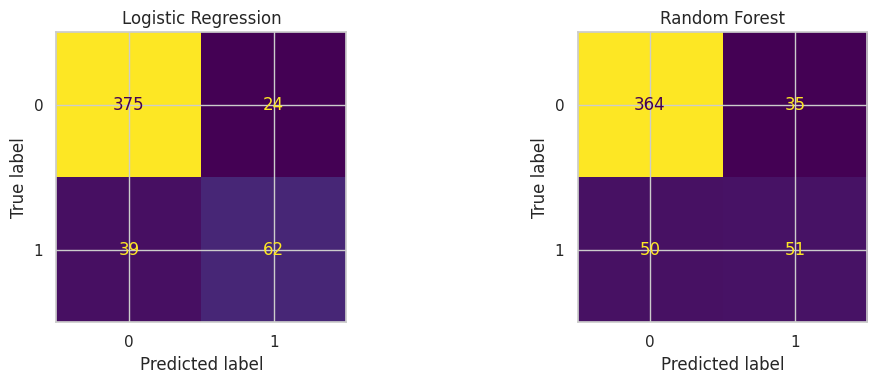

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


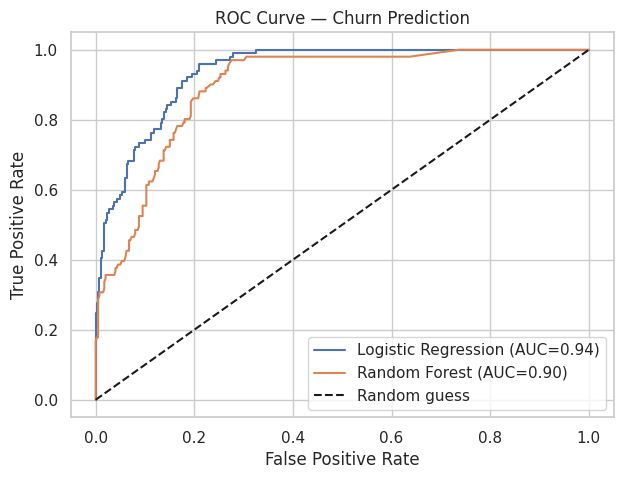

In [10]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_log):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Churn Prediction")
plt.legend()
plt.show()


### 1.6 Feature Importance (Random Forest)

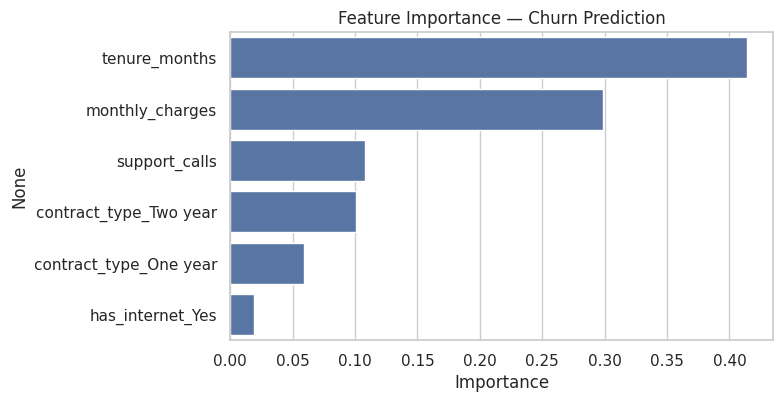

,0
tenure_months,0.414029
monthly_charges,0.298303
support_calls,0.108268
contract_type_Two year,0.100908
contract_type_One year,0.059169
has_internet_Yes,0.019324


In [11]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance — Churn Prediction")
plt.xlabel("Importance")
plt.show()

importances


**Takeaway:** tenure, support calls, and contract type drive churn risk the
most in this simulated dataset — a realistic pattern seen in real telecom
churn problems too.


---
## Project 2 — House Price Prediction
### *Supervised Learning: Regression*

**Goal:** predict a continuous target (house price) from property features.


### 2.1 Generate Synthetic Data

In [12]:
n_houses = 1500

area_sqft = np.random.normal(1800, 600, n_houses).clip(400, 5000)
bedrooms = np.random.randint(1, 6, n_houses)
age_years = np.random.randint(0, 50, n_houses)
location_score = np.random.uniform(1, 10, n_houses)  # 10 = prime location

# True price generating process + noise
price = (
    50_000
    + 120 * area_sqft
    + 8_000 * bedrooms
    - 800 * age_years
    + 15_000 * location_score
    + np.random.normal(0, 25_000, n_houses)
).clip(min=30_000)

df_house = pd.DataFrame({
    "area_sqft": area_sqft.round(0),
    "bedrooms": bedrooms,
    "age_years": age_years,
    "location_score": location_score.round(2),
    "price": price.round(0)
})

df_house.head()


,area_sqft,bedrooms,age_years,location_score,price
0,1907.0,1,30,7.00,345442.0
1,1696.0,3,1,6.29,408902.0
2,2398.0,3,15,6.60,414931.0
3,2242.0,4,0,3.30,413761.0
4,1210.0,3,3,3.15,289374.0


### 2.2 Exploratory Data Analysis (EDA)

In [13]:
df_house.describe()


,area_sqft,bedrooms,age_years,location_score,price
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,1810.544667,3.050000,24.218000,5.450267,354353.718000
std,591.225904,1.403619,14.449464,2.594887,87169.507473
min,400.000000,1.000000,0.000000,1.010000,77843.000000
25%,1404.750000,2.000000,12.000000,3.200000,294320.250000
50%,1807.000000,3.000000,24.000000,5.350000,354117.000000
75%,2210.500000,4.000000,37.000000,7.707500,413903.250000
max,3684.000000,5.000000,49.000000,10.000000,600590.000000


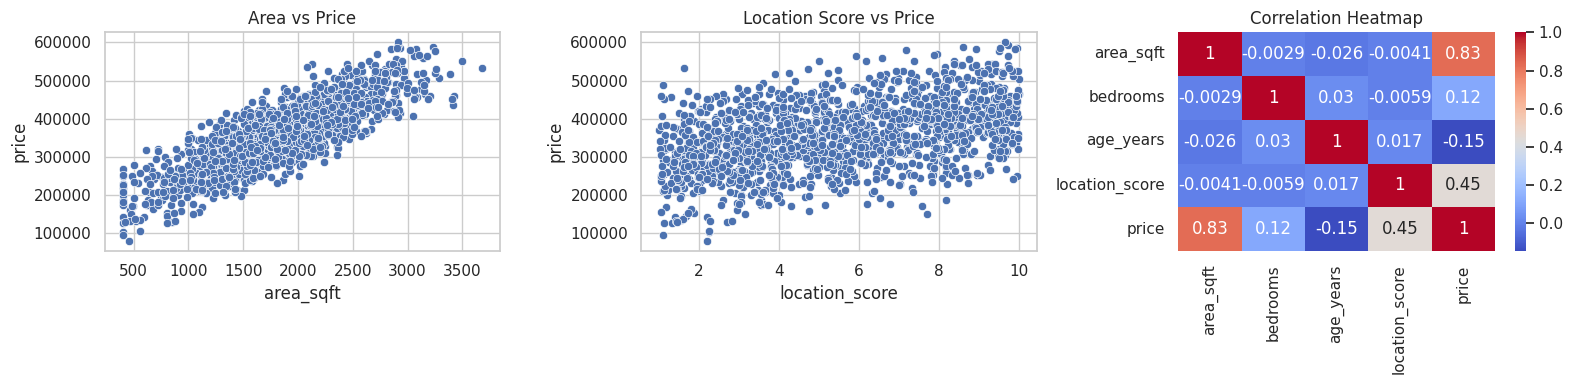

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(data=df_house, x="area_sqft", y="price", ax=axes[0])
axes[0].set_title("Area vs Price")

sns.scatterplot(data=df_house, x="location_score", y="price", ax=axes[1])
axes[1].set_title("Location Score vs Price")

sns.heatmap(df_house.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[2])
axes[2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()


### 2.3 Preprocessing

In [15]:
X = df_house.drop(columns=["price"])
y = df_house["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1125, 4)  Test shape: (375, 4)


### 2.4 Model Training — Linear Regression vs Random Forest

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)
y_pred_rf = rf_reg.predict(X_test)

print("Models trained.")


Models trained.


### 2.5 Evaluation

In [17]:
def regression_report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE : {mae:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R^2 : {r2:.3f}\n")

regression_report("Linear Regression", y_test, y_pred_lin)
regression_report("Random Forest Regressor", y_test, y_pred_rf)


--- Linear Regression ---
MAE : 18,760
RMSE: 23,947
R^2 : 0.922

--- Random Forest Regressor ---
MAE : 21,076
RMSE: 27,179
R^2 : 0.900



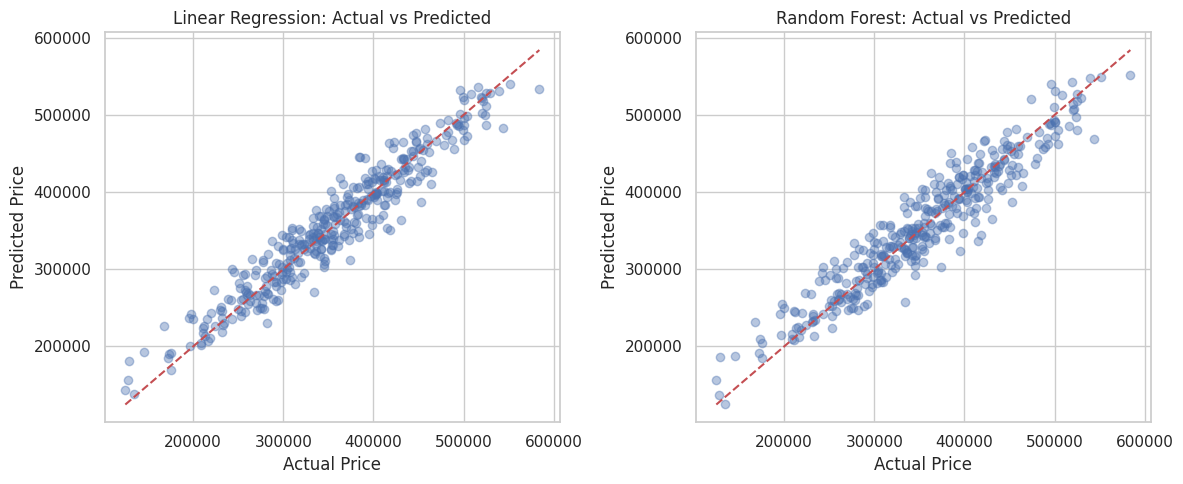

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, name in zip(axes, [y_pred_lin, y_pred_rf], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, y_pred, alpha=0.4)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{name}: Actual vs Predicted")

plt.tight_layout()
plt.show()


### 2.6 Feature Importance / Coefficients

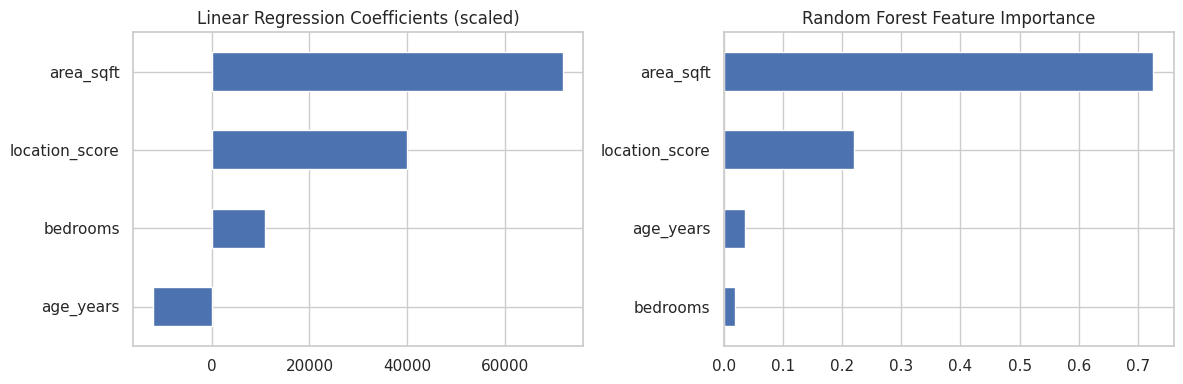

In [19]:
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coefs.plot(kind="barh", ax=axes[0], title="Linear Regression Coefficients (scaled)")
importances.plot(kind="barh", ax=axes[1], title="Random Forest Feature Importance")

plt.tight_layout()
plt.show()


**Takeaway:** area and location score dominate price in this simulated
market — consistent with real housing datasets like Boston/California
housing or Kaggle's House Prices competition.


---
## Project 3 — Customer Segmentation
### *Unsupervised Learning: Clustering*

**Goal:** group mall customers into segments based on income and spending
behaviour — **no labels are used**; the model discovers structure on its own.

This mirrors the well-known "Mall Customer Segmentation" dataset, generated
here synthetically as a mixture of customer archetypes (so real cluster
structure exists to discover).


### 3.1 Generate Synthetic Data

In [20]:
n_per_cluster = 150

# Define 5 customer archetypes: (age_mean, income_mean, spending_mean)
archetypes = [
    (25, 25, 80),   # young, low income, high spenders
    (45, 25, 20),   # mid-age, low income, low spenders (careful)
    (35, 70, 75),   # mid-age, high income, high spenders (target segment)
    (55, 70, 15),   # older, high income, low spenders (savers)
    (30, 45, 50),   # average / standard customers
]

rows = []
for age_m, income_m, spend_m in archetypes:
    age = np.random.normal(age_m, 5, n_per_cluster)
    income = np.random.normal(income_m, 8, n_per_cluster)
    spending = np.random.normal(spend_m, 10, n_per_cluster)
    rows.append(np.column_stack([age, income, spending]))

data = np.vstack(rows)
df_customers = pd.DataFrame(data, columns=["age", "annual_income_k", "spending_score"])
df_customers = df_customers.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)  # shuffle

df_customers.head()


,age,annual_income_k,spending_score
0,58.833090,63.923856,20.756440
1,26.803360,74.075146,67.457426
2,27.477853,35.892731,73.896260
3,43.917731,11.464774,32.544204
4,48.102670,32.586410,18.386181


### 3.2 Exploratory Data Analysis (EDA)

In [21]:
df_customers.describe()


,age,annual_income_k,spending_score
count,750.000000,750.000000,750.000000
mean,38.035926,46.960027,49.007897
std,11.952486,22.216676,28.528399
min,11.557329,-10.828178,-5.835268
25%,28.828650,27.142153,22.221377
50%,36.416067,44.750509,52.044180
75%,47.618269,68.169050,74.781277
max,67.833388,90.697029,111.147490


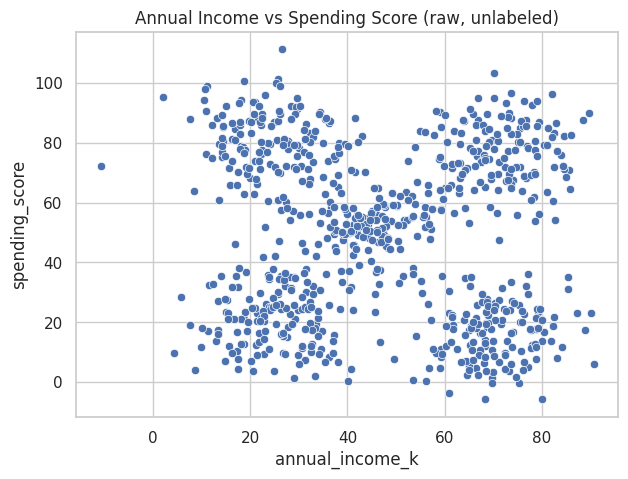

In [22]:
sns.scatterplot(data=df_customers, x="annual_income_k", y="spending_score")
plt.title("Annual Income vs Spending Score (raw, unlabeled)")
plt.show()


Notice we can *visually* guess there might be groups here — but we have no
`cluster` column. This is exactly the unsupervised learning setting.


### 3.3 Preprocessing

In [23]:
features = ["age", "annual_income_k", "spending_score"]
X = df_customers[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 3.4 Choosing K — Elbow Method & Silhouette Score

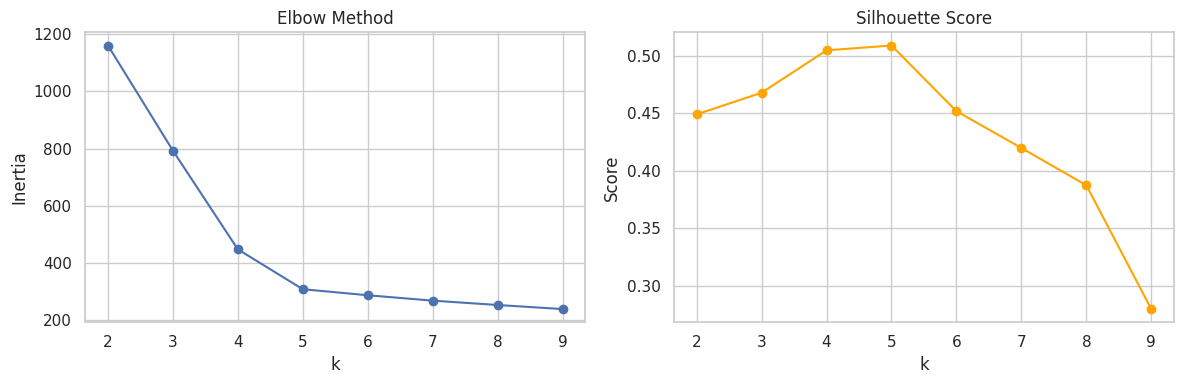

In [24]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouette_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()


### 3.5 Final Clustering (K = 5)

In [25]:
k_final = 5
kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df_customers["cluster"] = kmeans.fit_predict(X_scaled)

print("Silhouette score:", round(silhouette_score(X_scaled, df_customers["cluster"]), 3))
df_customers.head()


Silhouette score: 0.509


,age,annual_income_k,spending_score,cluster
0,58.833090,63.923856,20.756440,0
1,26.803360,74.075146,67.457426,3
2,27.477853,35.892731,73.896260,1
3,43.917731,11.464774,32.544204,2
4,48.102670,32.586410,18.386181,2


### 3.6 Visualizing Clusters (PCA to 2D)

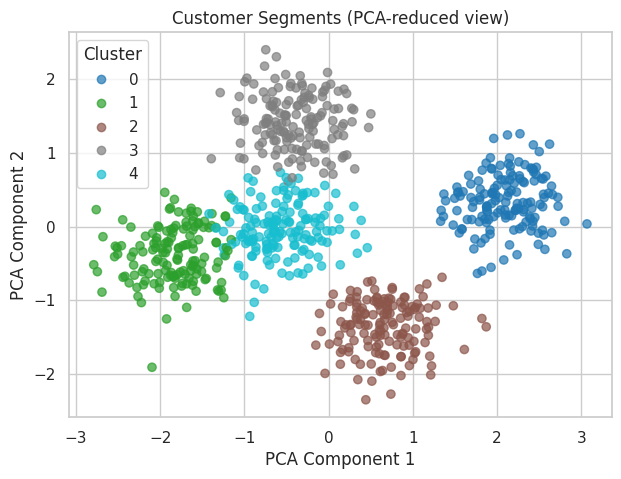

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_customers["cluster"], cmap="tab10", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments (PCA-reduced view)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


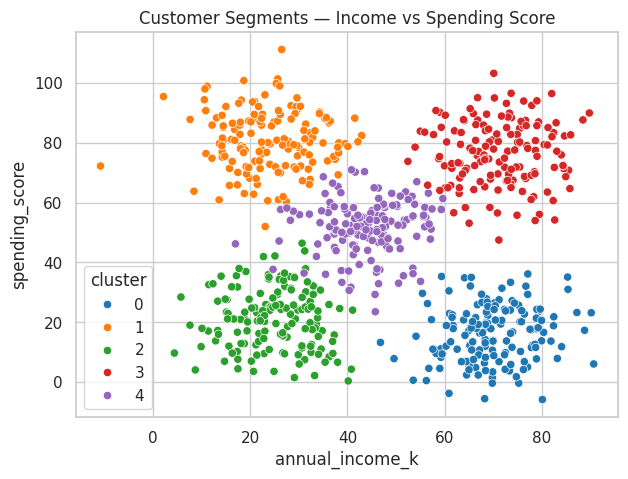

In [27]:
sns.scatterplot(
    data=df_customers, x="annual_income_k", y="spending_score",
    hue="cluster", palette="tab10"
)
plt.title("Customer Segments — Income vs Spending Score")
plt.show()


### 3.7 Cluster Profiling (Business Insights)

In [28]:
cluster_profile = df_customers.groupby("cluster")[features].mean().round(1)
cluster_profile["count"] = df_customers["cluster"].value_counts().sort_index()
cluster_profile


,age,annual_income_k,spending_score,count
cluster,,,,
0,55.4,70.0,16.1,150
1,24.7,23.8,80.6,147
2,44.9,25.0,21.1,150
3,34.9,71.4,76.3,150
4,30.1,44.2,51.6,153
